In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from run import initialize,train,test

In [10]:
n_units=10
k_sub = 5
n_families = 20
CONF = {
        "n_units": n_units,
        "n_families": n_families,
        "latent_dim": 3,
        "k_sub": k_sub,
        "batch_size": 1024,
        "epochs": 50000,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long), # size must be smaller or equal to n_units
        "init_means":[np.random.randint(1,8) for _ in range(n_families)], # size must be n_families
        "shape_sigma": 0.25
    }

Ns_train = [2**i for i in [16]]#,14,15,16]]
Ns_test = [2**i for i in [14]]

In [3]:
print(CONF)

{'n_units': 10, 'n_families': 10, 'latent_dim': 3, 'k_sub': 5, 'batch_size': 1024, 'epochs': 50000, 'lr': 0.05, 'cov_weight': 10.0, 'n_bins': 2, 'bin_temp': 0.05, 'receptor_indices': tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4],
        [5, 5, 5, 5, 5],
        [6, 6, 6, 6, 6],
        [7, 7, 7, 7, 7],
        [8, 8, 8, 8, 8],
        [9, 9, 9, 9, 9]]), 'init_means': [5, 4, 1, 3, 7, 4, 7, 6, 2, 2], 'shape_sigma': 0.35}


Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

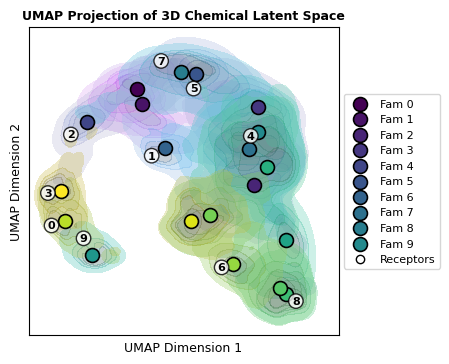

In [11]:
env,rec,loss_fn,optimize = initialize(CONF)
plot_latent_umap(env,CONF["receptor_indices"])

In [12]:
ents = []
stats=[]
for N_train in Ns_train:
    CONF['batch_size'] = N_train
    env,rec,loss_fn,optimize = initialize(CONF)
    stats.append(train(CONF,env,rec,loss_fn,optimize))
    ent=[]
    for N_test in Ns_test:
        ent.append(test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices']))
    ents.append(ent)
ents = np.array(ents)

Training for 50000 epochs...


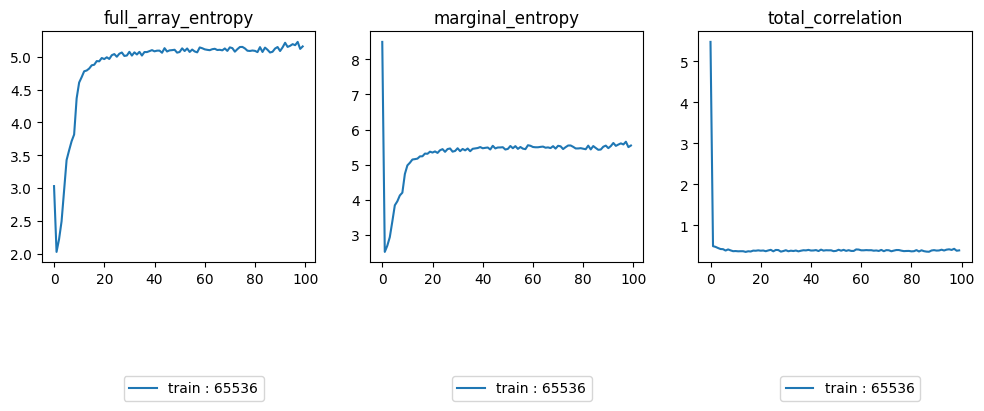

In [14]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
n=0
for stat in stats:    
    for i,key in enumerate(stat.keys()):
        ax[i].plot(stat[key],label=f'train : {Ns_train[n]}')
        ax[i].set_title(key)
    n+=1
for i in range(3):
    ax[i].legend(loc=(0.3,-.6))
#ax[2].set_ylim(0.1,0.6)

Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

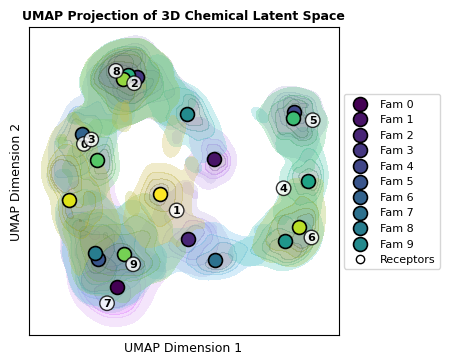

In [15]:
env,rec,loss_fn,optimize = initialize(CONF)
plot_latent_umap(env,CONF["receptor_indices"])

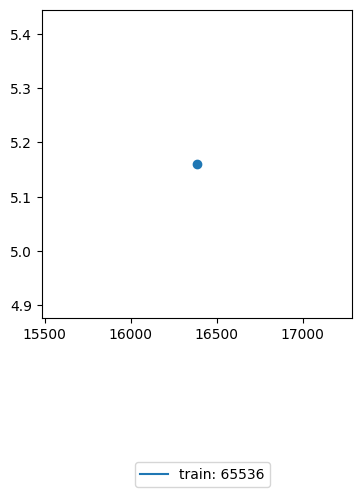

In [8]:
fig,ax = plt.subplots(ncols=1,nrows=1,figsize = ((1)*4,4))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = cycle(prop_cycle.by_key()['color'])
for i in range(ents.shape[0]):
    ax.plot(Ns_test,np.mean(ents[i,:],axis=1),label=f'train: {Ns_train[i]}')
    ax.scatter(Ns_test,np.mean(ents[i,:],axis=1))
ax.legend(loc=(0.3,-0.55))